In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

In [55]:
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [56]:
df.shape

(768, 9)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


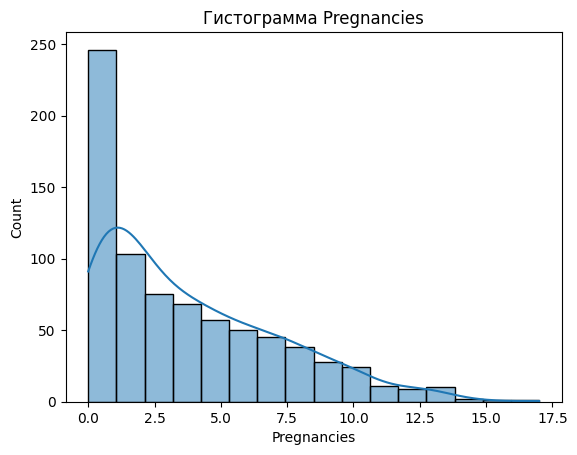

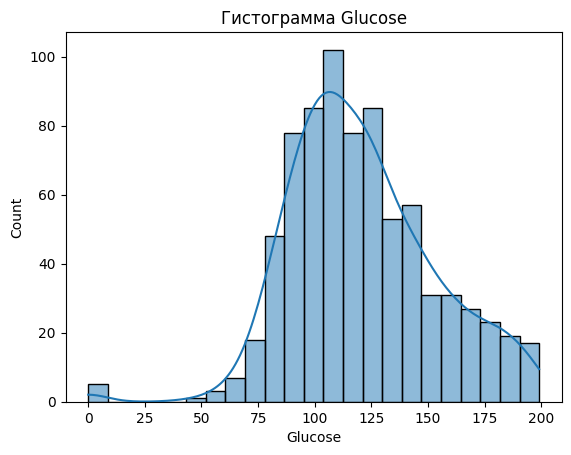

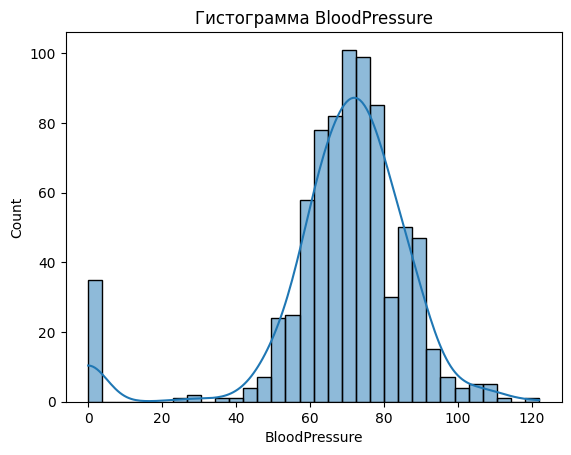

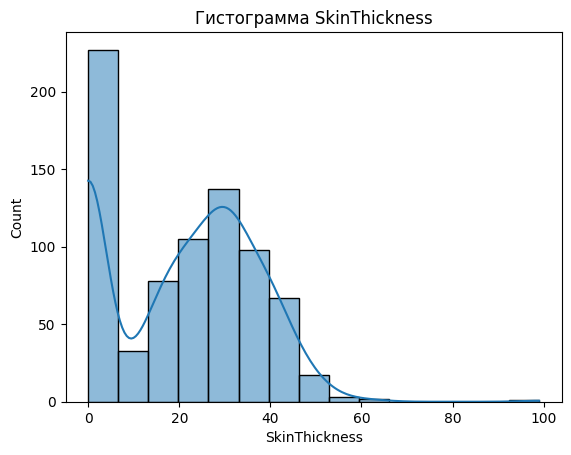

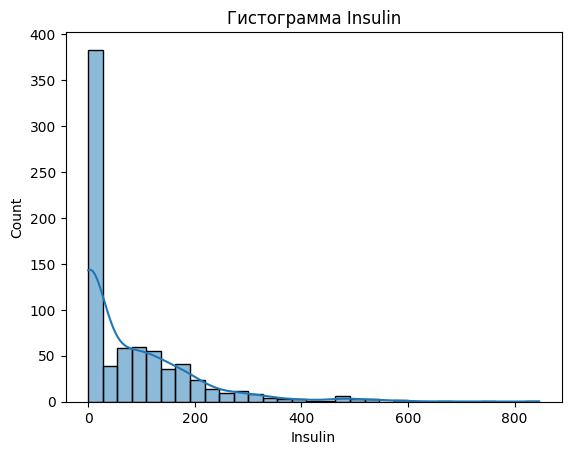

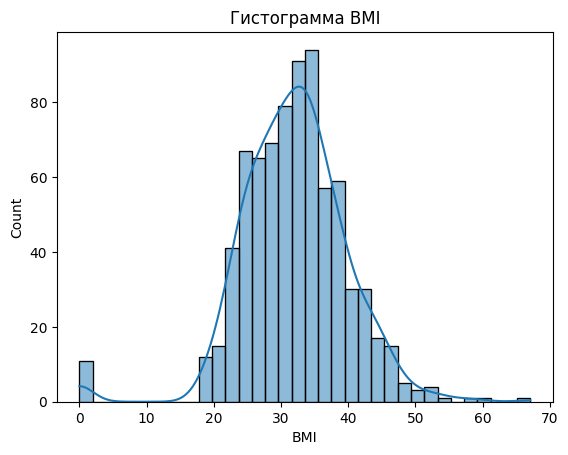

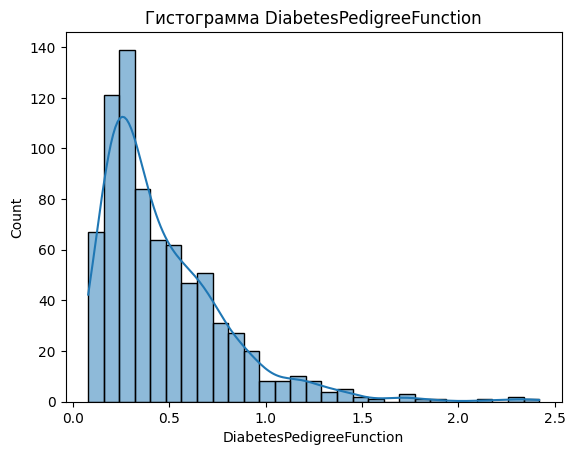

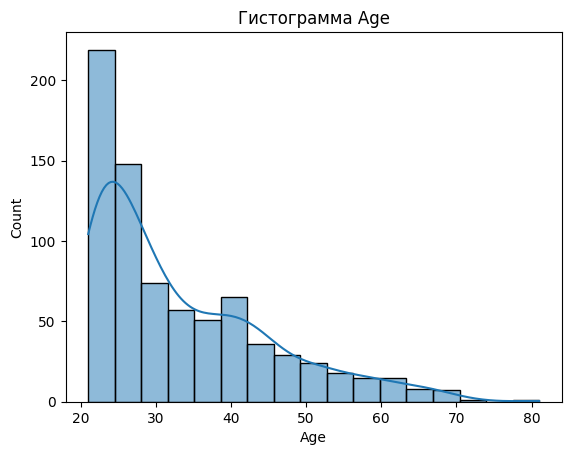

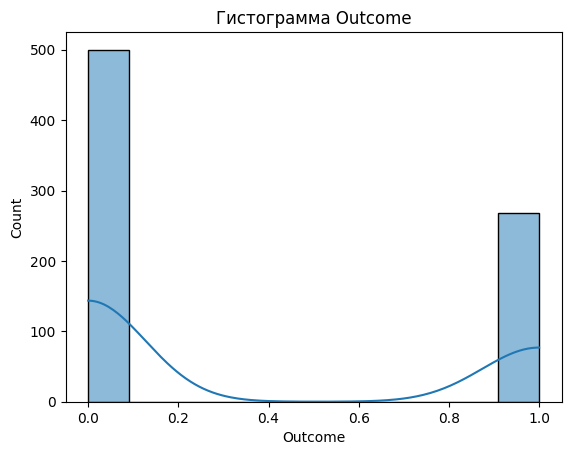

In [59]:
for col in df.columns:
    sns.histplot(x=df[col], kde=True,)
    plt.title(f'Гистограмма {col}')
    plt.show()

- Очень странно, что в столбцах `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` имеются нули, записанные как 0. В поле `Pregnancies` большое количество нулей обусловлено природой данных: поле означает количество беременностей, и большое количество женщин не рожали.

In [92]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

In [93]:
scaler = StandardScaler()

In [94]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [95]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [96]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.63994726,  0.86604475, -0.03198993, ...,  0.16661938,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20506583, -0.5283186 , ..., -0.85219976,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.01666174, -0.69376149, ..., -1.33250021,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.02157407, -0.03198993, ..., -0.910418  ,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14279979, -1.02464727, ..., -0.34279019,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94206766, -0.19743282, ..., -0.29912651,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [97]:
pca = PCA(
    n_components=2
)

In [98]:
X_scaled_pca = pca.fit_transform(X_scaled)
X_scaled_pca

array([[ 1.44948091,  0.65976875],
       [-1.49883475, -0.07604933],
       [ 0.42324603,  0.76132708],
       ...,
       [-0.87570123,  0.88805999],
       [-0.38529482,  0.23126666],
       [-1.22969382, -0.65397214]], shape=(768, 2))

In [99]:
df_scaled_pca = pd.DataFrame(
    X_scaled_pca,
    columns=['x', 'y']
)

df_scaled_pca['target'] = y
df_scaled_pca.head()

,x,y,target
0,1.449481,0.659769,1
1,-1.498835,-0.076049,0
2,0.423246,0.761327,1
3,-2.152468,-0.166717,0
4,0.697836,-3.548952,1


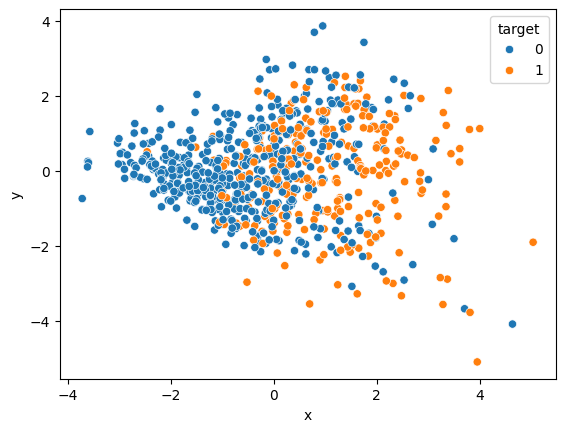

In [100]:
sns.scatterplot(data=df_scaled_pca, x='x', y='y', hue='target')
plt.show()

### Попробуем найти зависимые с target поля и сжать их

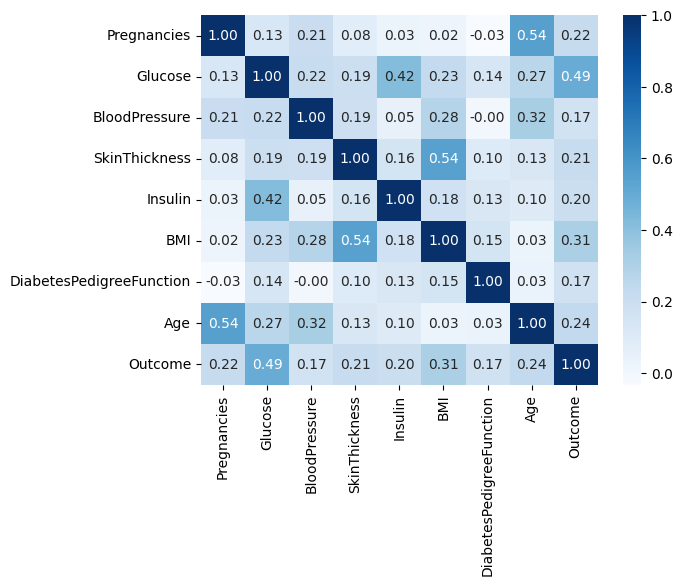

In [101]:
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.show()

In [102]:
X_scaled_pca = pca.fit_transform(X_scaled[:, [0, 1, 5, 7]])
X_scaled_pca

array([[ 1.7116531 ,  0.01039249],
       [-1.30569103, -0.92022805],
       [ 1.2854856 , -0.38895585],
       ...,
       [-0.15250175, -0.75316434],
       [ 0.24976725, -0.17334917],
       [-1.53186599, -0.20906806]], shape=(768, 2))

In [103]:
df_scaled_pca = pd.DataFrame(
    X_scaled_pca,
    columns=['x', 'y']
)
df_scaled_pca['target'] = y

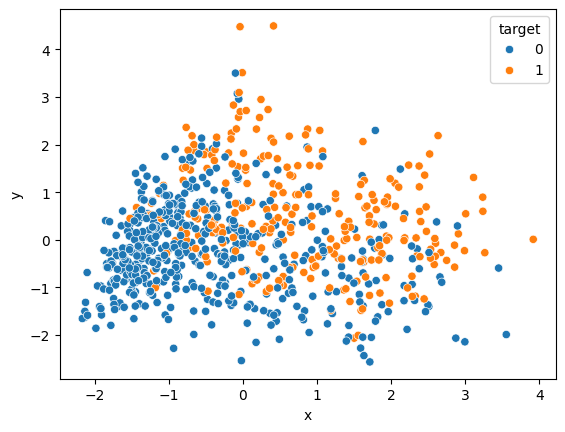

In [104]:
sns.scatterplot(data=df_scaled_pca, x='x', y='y', hue='target')
plt.show()

- Все равно данные очень сильно перекрываются

### Попробуем разные модели. Начнем с `LogisticRegression`

In [105]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

In [108]:
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__class_weight': [None, 'balanced']
}

In [109]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [110]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [111]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': [0.001, 0.01, ...], 'logisticregression__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,

In [112]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_pred, y_test))
print("f1_score:", f1_score(y_pred, y_test))

accuracy_score: 0.7077922077922078
f1_score: 0.6153846153846154


## Воспользуемся моделями с деревьями:
## `DecisionTree`, `RandomForest`, `XGBoost`

## `DecisionTree`

In [114]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [137]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,29.0,125.0,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


In [118]:
model = DecisionTreeClassifier(random_state=42)

In [119]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

In [120]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [121]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [122]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [123]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_pred, y_test))
print("f1_score:", f1_score(y_pred, y_test))

accuracy_score: 0.7597402597402597
f1_score: 0.6782608695652174


## `Random Forest`

In [127]:
model = RandomForestClassifier(random_state=42)

In [128]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

In [129]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [130]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_pred, y_test))
print("f1_score:", f1_score(y_pred, y_test))

accuracy_score: 0.7402597402597403
f1_score: 0.6774193548387096


## `XGBoost`

In [132]:
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [133]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [134]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable

In [135]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_pred, y_test))
print("f1_score:", f1_score(y_pred, y_test))

accuracy_score: 0.7662337662337663
f1_score: 0.6666666666666666


# Отчёт по проекту: прогнозирование диабета

## Цель работы

Целью проекта было построение и сравнение нескольких моделей машинного обучения для решения задачи бинарной классификации наличия диабета по медицинским показателям пациентов.

---

## Данные

В работе использовался датасет `diabetes.csv`, содержащий следующие признаки:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

Целевая переменная — `Outcome`, где:

- `0` — отсутствие диабета,
- `1` — наличие диабета.

---

## Предобработка данных

На этапе предварительной обработки были выполнены следующие действия:

- загружен и просмотрен исходный датасет;
- изучены размерность, типы данных и описательная статистика;
- построены гистограммы распределений признаков;
- обнаружены нули в столбцах `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`;
- выполнена замена нулей на `NaN` в указанных столбцах;
- пропущенные значения заполнены медианой соответствующего признака;
- признаки были стандартизированы с помощью `StandardScaler`.

Признак `Pregnancies` не был изменён, так как нулевое значение в нём является корректным и означает отсутствие беременностей.

---

## Анализ структуры данных

Для визуального анализа данных был применён метод главных компонент (`PCA`) с понижением размерности до двух компонент. После добавления целевой переменной и построения scatterplot было видно, что классы сильно перекрываются, то есть в двумерной проекции данные не образуют чётко разделимых групп.

Также была построена корреляционная матрица, чтобы оценить связь признаков с целевой переменной. На основе этого были дополнительно проверены наиболее информативные признаки, однако даже при выборе наиболее связанных полей сильного разделения классов в 2D не наблюдалось.

---

## Построение и сравнение моделей

Для решения задачи были обучены и сравнены несколько моделей:

- `LogisticRegression`
- `DecisionTreeClassifier`
- `RandomForestClassifier`
- `XGBClassifier`

Для каждой модели использовались:

- разбиение данных на обучающую и тестовую выборки;
- `StratifiedKFold` для кросс-валидации;
- `GridSearchCV` для подбора гиперпараметров;
- метрики качества `accuracy_score` и `f1_score`.

---

## Результаты

| Модель | Accuracy | F1-score |
|--------|----------|----------|
| LogisticRegression | 0.7078 | 0.6154 |
| DecisionTree | 0.7597 | 0.6783 |
| RandomForest | 0.7403 | 0.6774 |
| XGBoost | 0.7662 | 0.6667 |

---

## Анализ результатов

Из полученных результатов видно, что:

- `LogisticRegression` показала самый слабый результат среди рассмотренных моделей;
- `DecisionTree` и `RandomForest` дали более высокие значения метрик;
- `XGBoost` продемонстрировал наибольшую точность по метрике `accuracy_score`;
- при этом наилучшее значение `f1_score` было получено у `DecisionTree`.

Это говорит о том, что для данной задачи простая линейная модель недостаточно хорошо описывает структуру данных, а более гибкие нелинейные алгоритмы работают лучше.

---

## Вывод

В ходе работы был выполнен полный цикл анализа данных: от предварительной обработки и визуализации до обучения и сравнения нескольких моделей классификации. Было показано, что после замены некорректных нулевых значений, стандартизации и подбора гиперпараметров можно получить достаточно хорошие результаты предсказания диабета.

Наиболее качественные результаты среди рассмотренных моделей дали `DecisionTree`, `RandomForest` и `XGBoost`, что подтверждает наличие нелинейных зависимостей в данных. Полученные значения метрик показывают, что задача классификации решается удовлетворительно, но для дальнейшего улучшения качества можно дополнительно поработать с отбором признаков, балансировкой классов и более тонкой настройкой моделей.

---

## Используемые библиотеки

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scikit-learn`
- `xgboost`